<a href="https://colab.research.google.com/github/DL4CV-NPTEL/2026/blob/main/notebooks/Week%201/Week_1_Lecture_5_New.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

📺 [Lecture video](https://www.youtube.com/watch?v=LiuMJvpSbOU) &nbsp;|&nbsp; 📄 [Slides](https://github.com/DL4CV-NPTEL/2026/blob/main/Slides/Week%201/DL4CV_Week01_Part05.pdf)

In [1]:
# Week 1, Lecture 5: Linear Filtering
from IPython.display import HTML, display

VIDEO_ID = "LiuMJvpSbOU"

# YouTube's official embed markup. The `allow` list delegates the permissions the
# player needs; Colab renders outputs inside a nested iframe and without that
# delegation the player aborts with "Error 153".
display(HTML(f"""
<iframe width="720" height="405"
        src="https://www.youtube.com/embed/{VIDEO_ID}"
        title="YouTube video player" frameborder="0"
        allow="accelerometer; autoplay; clipboard-write; encrypted-media; gyroscope; picture-in-picture; web-share"
        referrerpolicy="strict-origin-when-cross-origin"
        allowfullscreen></iframe>
<p><a href="https://www.youtube.com/watch?v={VIDEO_ID}" target="_blank">Watch on YouTube</a></p>
"""))

# Week 1, Lecture 5: Linear Filtering, Correlation and Convolution

**NPTEL Deep Learning for Computer Vision** | Prof. Vineeth N Balasubramanian, IIT Hyderabad

Companion notebook for **§1.5 Image Filtering**.

**What you will learn**

- Filter an image by **cross-correlation** with a kernel, and compare the box and Gaussian filters.
- Understand why the Gaussian is preferred to the box filter for smoothing.
- Distinguish **correlation from convolution** (the kernel flip) and know when the difference matters.
- Use the properties of convolution: linearity, shift invariance, and **separability** for cheap large kernels.
- Handle the practical issues: choosing a filter size and padding the borders.
- Meet a non-linear alternative, the **median filter**, and see where it beats any linear filter.

**Contents**
1. Linear filters and cross-correlation
2. The box (moving average) filter
3. The Gaussian filter
4. Box vs Gaussian
5. Edge filters
6. Correlation vs convolution (the kernel flip)
7. Properties of convolution
8. Linear shift-invariant operators
9. Separability
10. Practical issues: filter size and padding
11. Beyond linear filters: the median filter

**How to run**  Runs on Colab or a local Jupyter, CPU only. Every image is bundled with `scikit-image`, so nothing is downloaded. Run the setup cell first, then go top to bottom.

## Review

The previous lecture grouped image operations into **point**, **local** and **global**. Histogram
equalization (a point operation) maps each intensity through the cumulative histogram
$c_k = \frac{1}{MN}\sum_{l=1}^{k} h(l)$, giving $\hat I = I_{MAX}\, c$. This lecture develops **local** linear
operations: filtering by correlation and convolution.

## Setup

Everything uses images bundled with `scikit-image`, so the notebook runs offline.

In [2]:
%matplotlib inline
import numpy as np
import matplotlib.pyplot as plt
from skimage import data, util
from scipy import ndimage

np.random.seed(0)
plt.rcParams['figure.figsize'] = (10, 4)
plt.rcParams['image.cmap']     = 'gray'

def annotate(ax, M, fmt='{:.0f}', color='red', fs=8):
    # write each value of matrix M onto an imshow axis
    for (i, j), v in np.ndenumerate(M):
        ax.text(j, i, fmt.format(v), ha='center', va='center', color=color, fontsize=fs)

## 1. Linear filters and cross-correlation

An **image filter** modifies each pixel from a function of its local neighbourhood. A **linear filter**
makes that function a weighted sum: each output pixel is a linear combination of nearby inputs, with weights
given by a small matrix $H$ called the **kernel** (or mask, or filter).

For a kernel of size $(2k+1)\times(2k+1)$, **cross-correlation** is

$$G(i, j) = \sum_{u=-k}^{k}\sum_{v=-k}^{k} H(u, v)\, I(i + u, j + v), \qquad G = H \otimes I$$

It is the dot product between the kernel and the local patch, evaluated at every pixel. A uniform kernel
$H = \frac{1}{(2k+1)^2}$ recovers the plain neighbourhood average.

In [3]:
# The worked example from the slide: a 3x3 patch and kernel give 6.5
patch  = np.array([[10, 5, 3],
                   [ 4, 5, 1],
                   [ 1, 1, 6]], float)
kernel = np.array([[0, 0,   0  ],
                   [0, 0.5, 0  ],
                   [0, 1,   0.5]], float)

print('elementwise product:\n', patch * kernel)
print('output G(i, j) =', (patch * kernel).sum())

elementwise product:
 [[0.  0.  0. ]
 [0.  2.5 0. ]
 [0.  1.  3. ]]
output G(i, j) = 6.5


A from-scratch implementation loops over the (few) kernel entries and accumulates shifted, weighted copies
of the image. This is vectorised over pixels and matches `scipy.ndimage.correlate`.

In [4]:
def cross_correlate(I, H, mode='constant'):
    I, H = I.astype(float), H.astype(float)
    kh, kw = H.shape
    ph, pw = kh // 2, kw // 2
    P = np.pad(I, ((ph, ph), (pw, pw)), mode=mode)
    G = np.zeros_like(I)
    for u in range(kh):
        for v in range(kw):
            G += H[u, v] * P[u:u + I.shape[0], v:v + I.shape[1]]
    return G

# convolution is correlation with a kernel flipped in both axes (shown in section 6)
def convolve(I, H, mode='constant'):
    return cross_correlate(I, H[::-1, ::-1], mode=mode)

img = data.camera().astype(float)
H   = np.ones((3, 3)) / 9
ours  = cross_correlate(img, H)
scipy = ndimage.correlate(img, H, mode='constant')
print('max |ours - scipy|:', np.abs(ours - scipy).max())

max |ours - scipy|: 8.526512829121202e-14


## 2. The box (moving average) filter

The moving average from the previous lecture is exactly cross-correlation with a **uniform** kernel
$H = \frac{1}{9}\,\mathbf{1}_{3\times3}$. Applied to the earlier grid, it turns the sharp `0/90` block into a
smooth ramp.

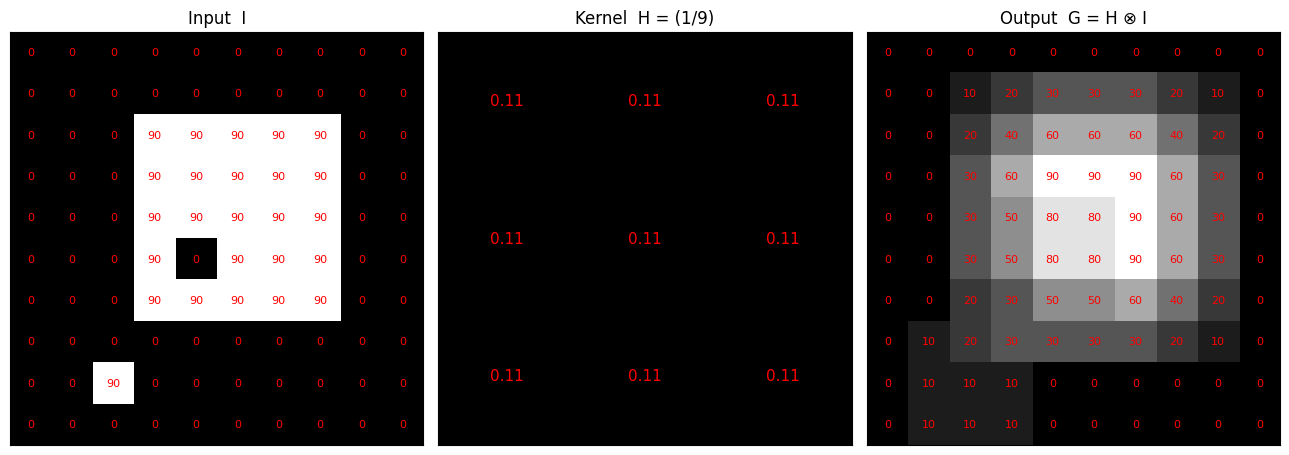

In [5]:
grid = np.zeros((10, 10))
grid[2:7, 3:8] = 90
grid[5, 4]     = 0
grid[8, 2]     = 90
box = np.ones((3, 3)) / 9
out = cross_correlate(grid, box)

fig, ax = plt.subplots(1, 3, figsize=(13, 4.5))
ax[0].imshow(grid, vmin=0, vmax=90); ax[0].set_title('Input  I'); annotate(ax[0], grid)
ax[1].imshow(box, cmap='gray');      ax[1].set_title('Kernel  H = (1/9)'); annotate(ax[1], box, fmt='{:.2f}', fs=11)
ax[2].imshow(out, vmin=0, vmax=90);  ax[2].set_title('Output  G = H \u2297 I'); annotate(ax[2], out)
for a in ax: a.set_xticks([]); a.set_yticks([])
plt.tight_layout(); plt.show()

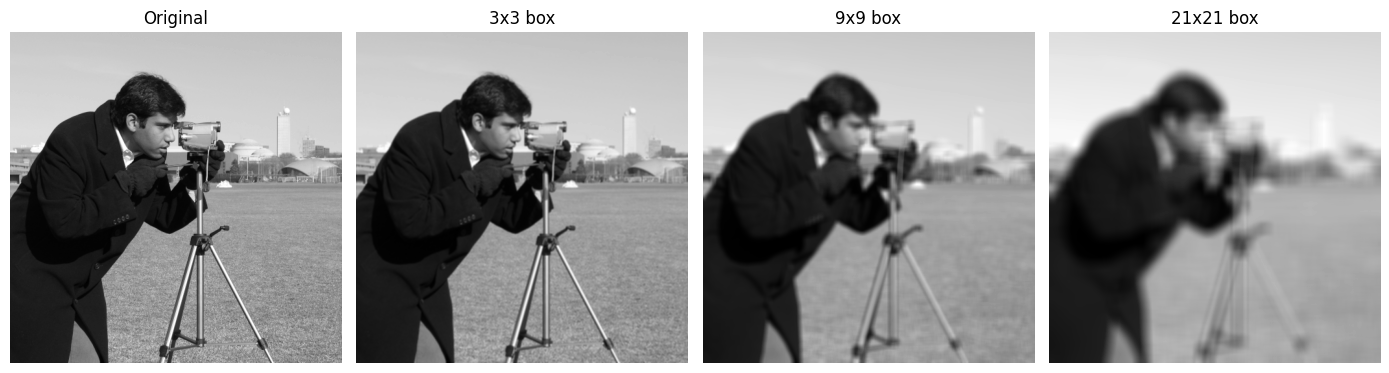

In [6]:
# Box blur of increasing size on a real image (uniform_filter == box correlation)
img = data.camera().astype(float)
fig, ax = plt.subplots(1, 4, figsize=(14, 4))
ax[0].imshow(img); ax[0].set_title('Original'); ax[0].axis('off')
for a, k in zip(ax[1:], [3, 9, 21]):
    a.imshow(ndimage.uniform_filter(img, size=k)); a.set_title(f'{k}x{k} box'); a.axis('off')
plt.tight_layout(); plt.show()

## 3. The Gaussian filter

The box filter weights every neighbour equally. Often we want nearer pixels to count more, which gives the
**Gaussian** kernel, a sampled and normalised 2D Gaussian

$$h(u, v) = \frac{1}{2\pi\sigma^2}\exp\!\left(-\frac{u^2 + v^2}{2\sigma^2}\right)$$

The familiar $\frac{1}{16}\begin{bmatrix}1&2&1\\2&4&2\\1&2&1\end{bmatrix}$ is the small binomial approximation.

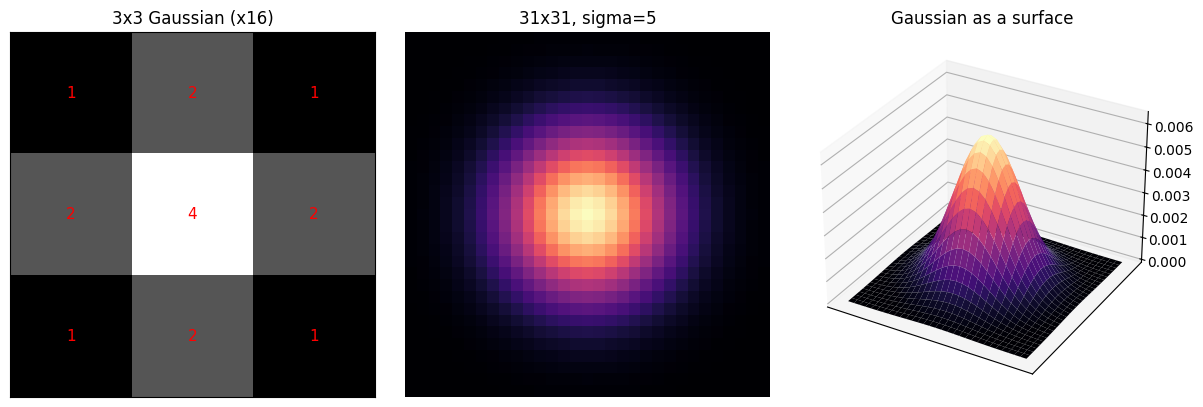

In [7]:
def gaussian_kernel(size, sigma):
    ax = np.arange(size) - size // 2
    xx, yy = np.meshgrid(ax, ax)
    k = np.exp(-(xx**2 + yy**2) / (2 * sigma**2))
    return k / k.sum()

G3 = np.array([[1, 2, 1], [2, 4, 2], [1, 2, 1]], float) / 16
big = gaussian_kernel(31, 5)

fig = plt.figure(figsize=(12, 4))
ax1 = fig.add_subplot(131); ax1.imshow(G3); annotate(ax1, G3 * 16, fmt='{:.0f}', fs=11)
ax1.set_title('3x3 Gaussian (x16)'); ax1.set_xticks([]); ax1.set_yticks([])
ax2 = fig.add_subplot(132); ax2.imshow(big, cmap='magma'); ax2.set_title('31x31, sigma=5'); ax2.axis('off')
X, Y = np.meshgrid(np.arange(31), np.arange(31))
ax3 = fig.add_subplot(133, projection='3d'); ax3.plot_surface(X, Y, big, cmap='magma', linewidth=0)
ax3.set_title('Gaussian as a surface'); ax3.set_xticks([]); ax3.set_yticks([])
plt.tight_layout(); plt.show()

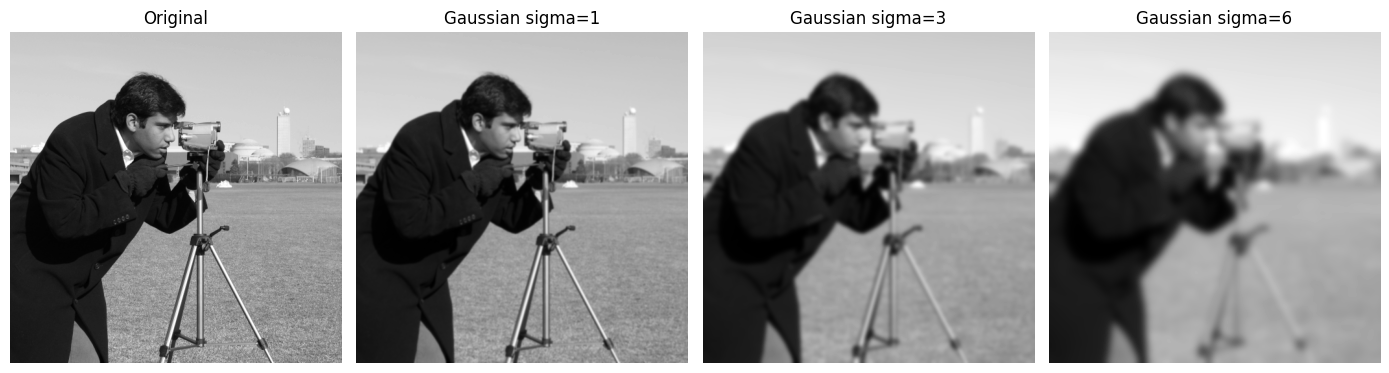

In [8]:
img = data.camera().astype(float)
fig, ax = plt.subplots(1, 4, figsize=(14, 4))
ax[0].imshow(img); ax[0].set_title('Original'); ax[0].axis('off')
for a, s in zip(ax[1:], [1, 3, 6]):
    a.imshow(ndimage.gaussian_filter(img, sigma=s)); a.set_title(f'Gaussian sigma={s}'); a.axis('off')
plt.tight_layout(); plt.show()

## 4. Box vs Gaussian

At a similar amount of blur, the box filter leaves blocky, directional artifacts (its kernel has hard
edges), while the Gaussian gives smooth, isotropic blur. The kernels themselves explain the difference.

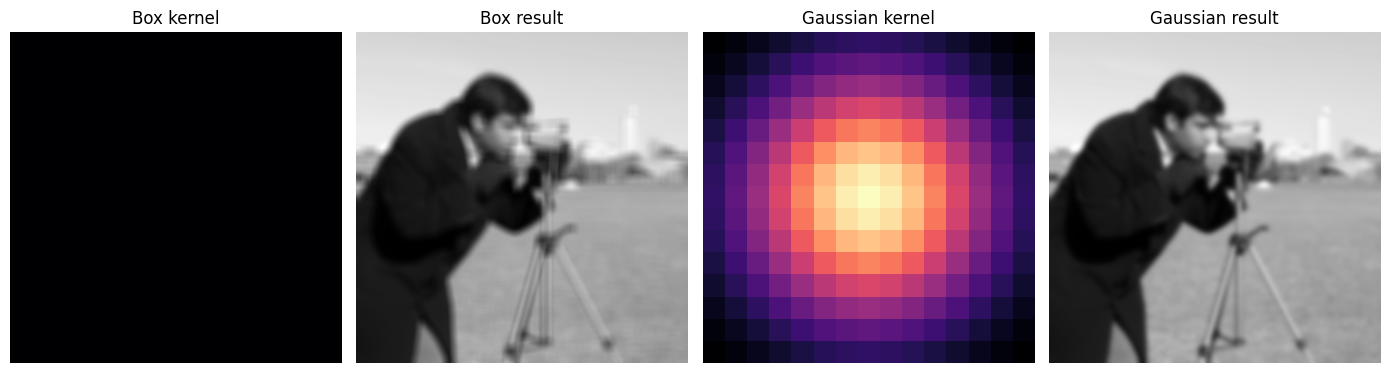

In [9]:
img = data.camera().astype(float)
box_k = np.ones((15, 15)) / 225
gau_k = gaussian_kernel(15, 4)
box_r = ndimage.uniform_filter(img, size=15)
gau_r = ndimage.gaussian_filter(img, sigma=4)

fig, ax = plt.subplots(1, 4, figsize=(14, 4))
ax[0].imshow(box_k, cmap='magma'); ax[0].set_title('Box kernel');      ax[0].axis('off')
ax[1].imshow(box_r);               ax[1].set_title('Box result');      ax[1].axis('off')
ax[2].imshow(gau_k, cmap='magma'); ax[2].set_title('Gaussian kernel'); ax[2].axis('off')
ax[3].imshow(gau_r);               ax[3].set_title('Gaussian result'); ax[3].axis('off')
plt.tight_layout(); plt.show()

## 5. Edge filters

Edges are large local intensity changes, so a kernel that estimates a derivative highlights them. The
**Sobel** kernels approximate horizontal and vertical gradients:

$$H_x = \tfrac{1}{8}\begin{bmatrix}-1&0&1\\-2&0&2\\-1&0&1\end{bmatrix}, \qquad
  H_y = \tfrac{1}{8}\begin{bmatrix}-1&-2&-1\\0&0&0\\1&2&1\end{bmatrix}$$

$H_x$ responds to vertical edges, $H_y$ to horizontal edges. The edge strength is the gradient magnitude
$|G| = \sqrt{G_x^2 + G_y^2}$. (The simpler Prewitt kernels from the slide use uniform $\pm1$ columns/rows.)

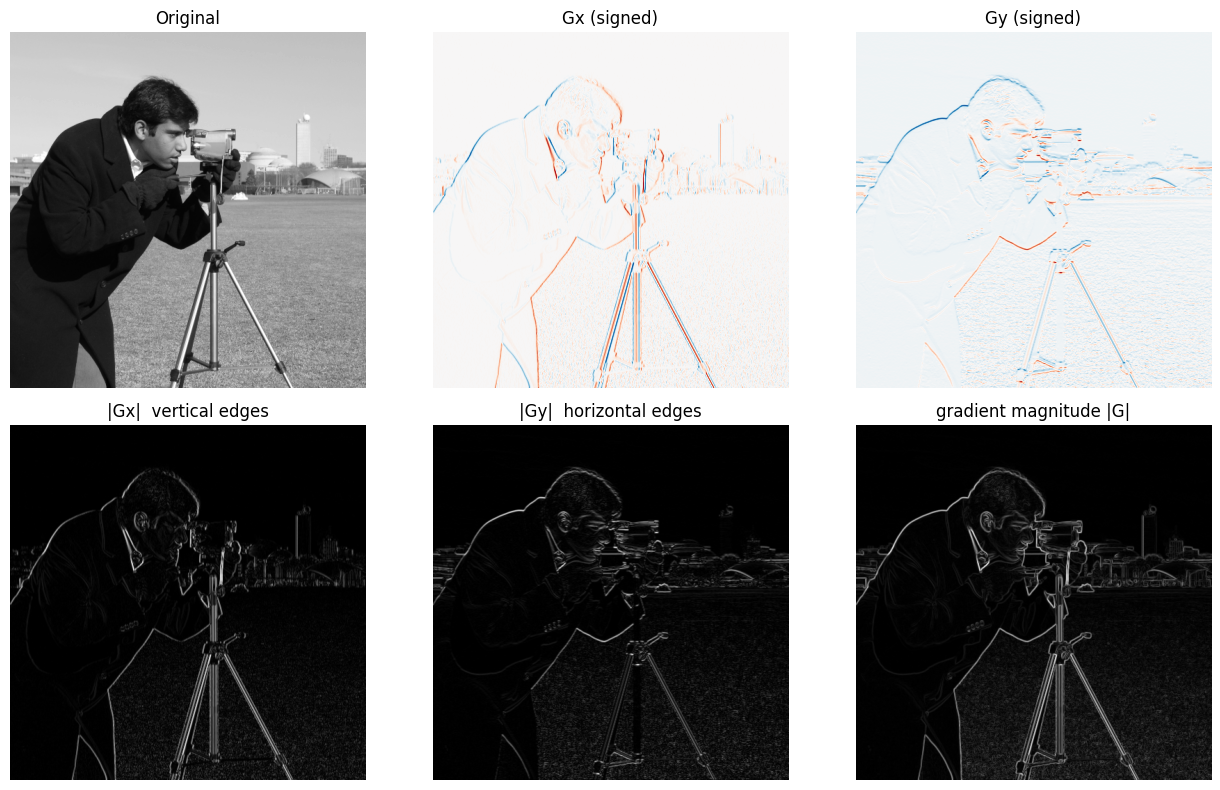

In [10]:
img = data.camera().astype(float)
Hx = np.array([[-1, 0, 1], [-2, 0, 2], [-1, 0, 1]], float) / 8
Hy = Hx.T
Gx = ndimage.convolve(img, Hx, mode='reflect')
Gy = ndimage.convolve(img, Hy, mode='reflect')
mag = np.hypot(Gx, Gy)

fig, ax = plt.subplots(2, 3, figsize=(13, 8))
ax[0, 0].imshow(img); ax[0, 0].set_title('Original')
ax[0, 1].imshow(Gx, cmap='RdBu'); ax[0, 1].set_title('Gx (signed)')
ax[0, 2].imshow(Gy, cmap='RdBu'); ax[0, 2].set_title('Gy (signed)')
ax[1, 0].imshow(np.abs(Gx)); ax[1, 0].set_title('|Gx|  vertical edges')
ax[1, 1].imshow(np.abs(Gy)); ax[1, 1].set_title('|Gy|  horizontal edges')
ax[1, 2].imshow(mag);        ax[1, 2].set_title('gradient magnitude |G|')
for a in ax.ravel(): a.axis('off')
plt.tight_layout(); plt.show()

## 6. Correlation vs convolution (the kernel flip)

**Convolution** is defined with subtraction of the kernel offset:

$$G(i, j) = \sum_{u=-k}^{k}\sum_{v=-k}^{k} H(u, v)\, I(i - u, j - v), \qquad G = H * I$$

This is equivalent to flipping the kernel in both directions and then cross-correlating. The cleanest way to
see the difference is to filter an **impulse** (a single bright pixel): correlation prints the kernel
**flipped** (rotated 180 degrees), convolution prints it **as is**.

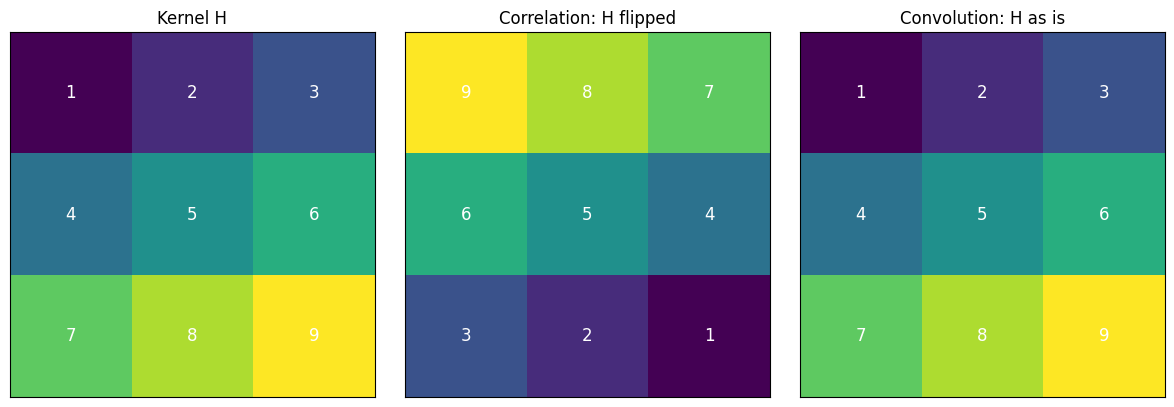

In [11]:
imp = np.zeros((9, 9)); imp[4, 4] = 1
H   = np.arange(1, 10).reshape(3, 3).astype(float)   # asymmetric, so the flip is visible
corr = ndimage.correlate(imp, H, mode='constant')[3:6, 3:6]
conv = ndimage.convolve(imp, H, mode='constant')[3:6, 3:6]

fig, ax = plt.subplots(1, 3, figsize=(12, 4))
ax[0].imshow(H, cmap='viridis');    ax[0].set_title('Kernel H');                 annotate(ax[0], H, fs=12, color='white')
ax[1].imshow(corr, cmap='viridis'); ax[1].set_title('Correlation: H flipped');  annotate(ax[1], corr, fs=12, color='white')
ax[2].imshow(conv, cmap='viridis'); ax[2].set_title('Convolution: H as is');    annotate(ax[2], conv, fs=12, color='white')
for a in ax: a.set_xticks([]); a.set_yticks([])
plt.tight_layout(); plt.show()

For **symmetric** kernels (box, Gaussian) the flip changes nothing, so correlation and convolution agree.
That is why the distinction did not matter in the blurring examples above. It matters for asymmetric kernels,
and convolution is the version with the clean algebraic properties below.

## 7. Properties of convolution

Convolution is **commutative**, **associative**, **distributive** over addition, and has the unit impulse as
**identity**. Two consequences are useful in practice: filtering by the impulse returns the image unchanged,
and applying two Gaussians in sequence equals one Gaussian with $\sigma = \sqrt{\sigma_1^2 + \sigma_2^2}$
(associativity, since a chain of filters can be merged into one).

In [12]:
img = data.camera().astype(float)

# identity: convolving with the unit impulse returns the image
impulse_kernel = np.array([[0, 0, 0], [0, 1, 0], [0, 0, 0]], float)
print('identity, max |conv(I, e) - I|:', np.abs(ndimage.convolve(img, impulse_kernel) - img).max())

# associativity: blur sigma=3 then sigma=4 equals a single blur sigma=5
seq      = ndimage.gaussian_filter(ndimage.gaussian_filter(img, 3), 4)
combined = ndimage.gaussian_filter(img, np.hypot(3, 4))   # sqrt(9 + 16) = 5
print('associativity, max |seq - combined|:', np.abs(seq - combined).max())

identity, max |conv(I, e) - I|: 0.0
associativity, max |seq - combined|: 0.005787261599863314


## 8. Linear shift-invariant operators

Correlation and convolution are **linear shift-invariant (LSI)** operators. Linearity (superposition) means
$I \circ (a h_0 + b h_1) = a(I \circ h_0) + b(I \circ h_1)$; shift-invariance means the operator commutes with
translation, so its effect is identical everywhere in the image. This is the property a convolutional layer
inherits: one small kernel is reused at every location (weight sharing). It also echoes early visual
neuroscience, where Hubel and Wiesel showed that simple cells respond to oriented edges by linear spatial
summation over a local receptive field.

In [13]:
img = util.img_as_float(data.camera())
f   = lambda x: ndimage.gaussian_filter(x, 2, mode='wrap')   # wrap matches circular np.roll
I1, I2 = img, np.roll(img, 30, axis=1)
a, b = 0.3, 0.7

lin = np.abs(f(a * I1 + b * I2) - (a * f(I1) + b * f(I2))).max()
shift = np.abs(f(np.roll(img, 25, axis=0)) - np.roll(f(img), 25, axis=0)).max()
print('linearity error      :', lin)
print('shift-invariance error:', shift)

linearity error      : 4.440892098500626e-16
shift-invariance error: 0.0


## 9. Separability

A 2D convolution costs $k^2$ operations per pixel. If the kernel is **separable**, $K = v\,h^{T}$ for 1D
kernels $v, h$, it can be applied as a 1D vertical pass followed by a 1D horizontal pass, costing only $2k$
operations per pixel. A kernel is separable exactly when its **SVD** has a single non-zero singular value;
then $\sqrt{\sigma_1}\,u_1$ and $\sqrt{\sigma_1}\,v_1$ are the 1D kernels.

In [14]:
G3    = np.array([[1, 2, 1], [2, 4, 2], [1, 2, 1]], float) / 16
sobel = np.array([[-1, 0, 1], [-2, 0, 2], [-1, 0, 1]], float) / 8
rand  = np.random.rand(3, 3)                          # generically not separable

for name, K in [('Gaussian', G3), ('Sobel', sobel), ('Random', rand)]:
    s = np.linalg.svd(K, compute_uv=False)
    print(f'{name:9s} singular values {np.round(s, 3)}  -> separable: {np.sum(s > 1e-10) == 1}')

# recover the 1D factors of the Gaussian from its SVD
U, S, Vt = np.linalg.svd(G3)
v = U[:, 0] * np.sqrt(S[0])
h = Vt[0, :] * np.sqrt(S[0])
if v.sum() < 0:
    v, h = -v, -h                                     # sign is arbitrary; pick the positive factor
print('\nrecovered v:', np.round(v, 3))
print('reconstruction error:', np.abs(np.outer(v, h) - G3).max())

Gaussian  singular values [0.375 0.    0.   ]  -> separable: True
Sobel     singular values [0.433 0.    0.   ]  -> separable: True
Random    singular values [1.972 0.26  0.165]  -> separable: False

recovered v: [0.25 0.5  0.25]
reconstruction error: 5.551115123125783e-17


In [15]:
# Timing: full 2D convolution vs two 1D passes, large Gaussian
import time
img  = data.camera().astype(float)
K2d  = gaussian_kernel(31, 5)
k1d  = np.exp(-(np.arange(31) - 15)**2 / (2 * 5**2)); k1d /= k1d.sum()

t = time.time(); full = ndimage.convolve(img, K2d, mode='reflect');         t2d = time.time() - t
t = time.time()
sep = ndimage.convolve1d(ndimage.convolve1d(img, k1d, axis=0, mode='reflect'),
                         k1d, axis=1, mode='reflect');                       tsep = time.time() - t

print(f'2D convolution : {t2d*1000:6.1f} ms')
print(f'separable 1D x2: {tsep*1000:6.1f} ms   ({t2d/tsep:.1f}x faster)')
print('max |full - separable|:', np.abs(full - sep).max())

2D convolution :  207.3 ms
separable 1D x2:    3.0 ms   (68.9x faster)
max |full - separable|: 1.0516032489249483e-12


## 10. Practical issues: filter size and padding

**Size.** A larger kernel pulls in more neighbours, so it suppresses noise more but also blurs more and costs
more to compute.

**Boundaries.** At the image border the kernel hangs off the edge, so we must invent values there. Common
strategies are zero padding, clamping (repeat the edge pixel), wrapping around, and mirroring (reflect). The
choice mainly affects a thin band near the border.

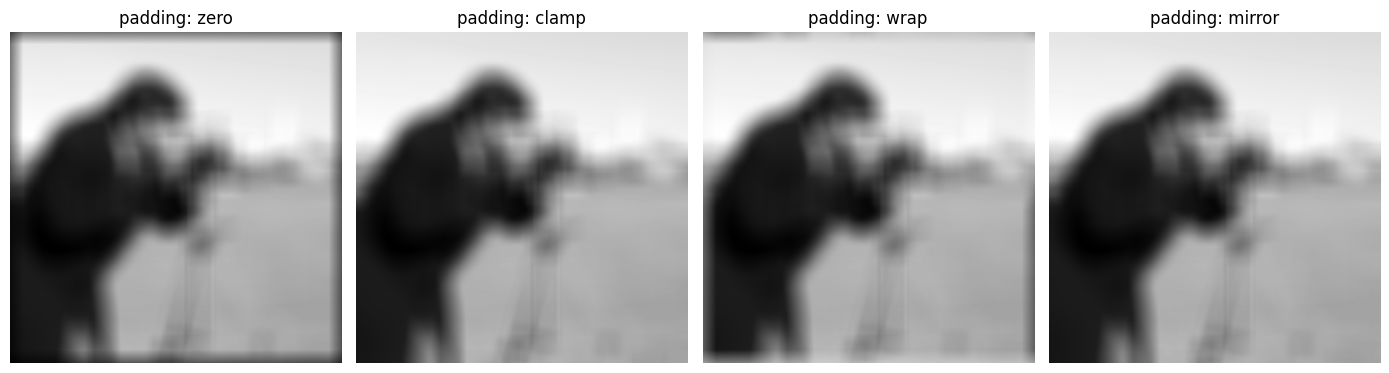

In [16]:
img = data.camera().astype(float)
modes = [('constant', 'zero'), ('nearest', 'clamp'), ('wrap', 'wrap'), ('reflect', 'mirror')]

fig, ax = plt.subplots(1, 4, figsize=(14, 4))
for a, (m, label) in zip(ax, modes):
    a.imshow(ndimage.uniform_filter(img, size=41, mode=m))
    a.set_title(f'padding: {label}'); a.axis('off')
plt.tight_layout(); plt.show()

## 11. Beyond linear filters: the median filter

Not every useful filter is linear. The **median filter** replaces each pixel by the median of its
neighbourhood. On salt-and-pepper noise it removes the outliers cleanly, whereas linear smoothers (box,
Gaussian) merely spread each spike into a grey smudge. This answers the closing question of the lecture:
filters need not be linear.

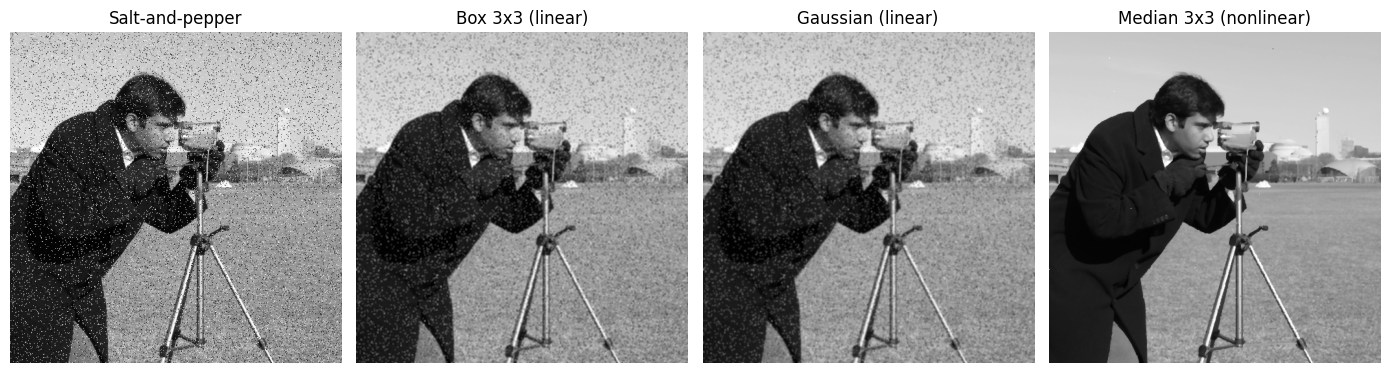

In [17]:
img   = util.img_as_float(data.camera())
noisy = util.random_noise(img, mode='s&p', amount=0.08)

fig, ax = plt.subplots(1, 4, figsize=(14, 4))
ax[0].imshow(noisy);                                  ax[0].set_title('Salt-and-pepper')
ax[1].imshow(ndimage.uniform_filter(noisy, size=3));  ax[1].set_title('Box 3x3 (linear)')
ax[2].imshow(ndimage.gaussian_filter(noisy, 1));      ax[2].set_title('Gaussian (linear)')
ax[3].imshow(ndimage.median_filter(noisy, size=3));   ax[3].set_title('Median 3x3 (nonlinear)')
for a in ax: a.axis('off')
plt.tight_layout(); plt.show()

## 12. Explore and verify

This lecture made three structural claims about linear filtering: that convolution is
correlation with a flipped kernel, that a 2D Gaussian is separable into two 1D passes, and
that our from-scratch correlation matches the library. Each is checkable in one line, so
we check them, then sweep $\sigma$.

In [18]:
# Verify the structural claims.
from scipy.ndimage import correlate as nd_correlate

img = data.camera().astype(float)

# 1. Convolution equals correlation with a flipped kernel (use an asymmetric kernel,
#    or the claim is vacuous).
H = np.array([[1., 2., 3.],
              [4., 5., 6.],
              [7., 8., 9.]])
assert np.allclose(convolve(img, H), cross_correlate(img, H[::-1, ::-1])), 'flip identity fails'
assert not np.allclose(convolve(img, H), cross_correlate(img, H)), 'kernel is symmetric; test is vacuous'

# 2. A 2D Gaussian is separable: one 2D pass == two 1D passes.
sigma, size = 2.0, 13
G2 = gaussian_kernel(size, sigma)
g1 = G2[size // 2] / G2[size // 2].sum()
sep = cross_correlate(cross_correlate(img, g1[None, :]), g1[:, None])
full = cross_correlate(img, G2)
m = (slice(size, -size), slice(size, -size))
assert np.allclose(sep[m], full[m], atol=1e-6), 'separable pass disagrees with the 2D pass'

# 3. Our correlation matches scipy.
assert np.allclose(cross_correlate(img, G2)[m],
                   nd_correlate(img, G2, mode='constant')[m], atol=1e-6)

print('all three checks passed')
print(f'  separable vs 2D, max |difference| = {np.abs(sep[m] - full[m]).max():.2e}')
print(f'  a {size}x{size} 2D pass costs {size*size} multiplies per pixel; '
      f'two 1D passes cost {2*size}')

all three checks passed
  separable vs 2D, max |difference| = 4.83e-13
  a 13x13 2D pass costs 169 multiplies per pixel; two 1D passes cost 26


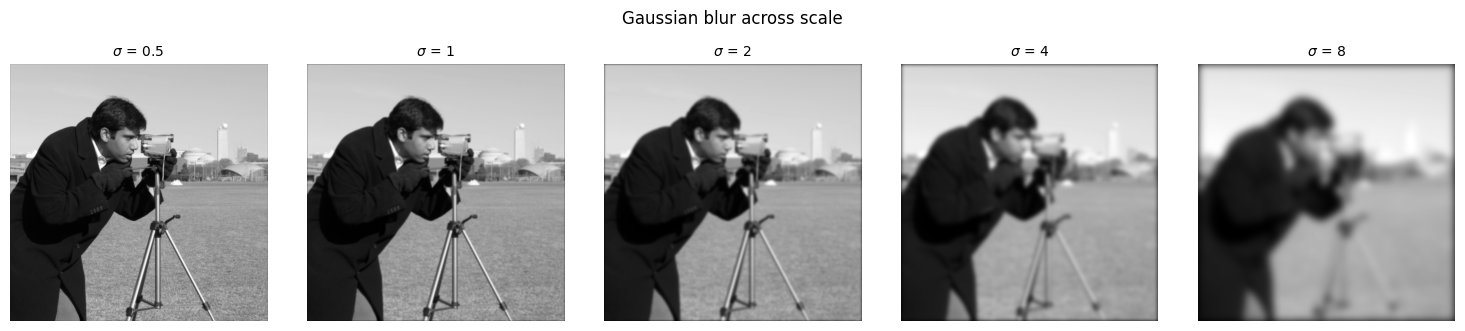

In [19]:
# Static sweep: sigma controls how much structure survives.
fig, ax = plt.subplots(1, 5, figsize=(15, 3.2))
for a, s in zip(ax, [0.5, 1, 2, 4, 8]):
    K = gaussian_kernel(int(6 * s) | 1, s)
    a.imshow(cross_correlate(img, K), cmap='gray'); a.set_axis_off()
    a.set_title(f'$\\sigma$ = {s}', fontsize=10)
fig.suptitle('Gaussian blur across scale', y=1.02)
plt.tight_layout(); plt.show()

Now the same thing under your control. Drag the slider and watch what changes.

In [20]:
# Live: compare the Gaussian against the box filter at matched width.
from ipywidgets import interact, FloatSlider

def compare(sigma=2.0):
    size = int(6 * sigma) | 1
    g = cross_correlate(img, gaussian_kernel(size, sigma))
    b = cross_correlate(img, np.ones((size, size)) / size ** 2)
    fig, ax = plt.subplots(1, 2, figsize=(9, 4.4))
    ax[0].imshow(g, cmap='gray'); ax[0].set_title(f'Gaussian, $\\sigma$={sigma:.1f} (size {size})')
    ax[1].imshow(b, cmap='gray'); ax[1].set_title(f'Box, size {size}')
    for a in ax: a.set_axis_off()
    plt.tight_layout(); plt.show()

interact(compare, sigma=FloatSlider(min=0.5, max=8, step=0.5, value=2.0, description='sigma'));

interactive(children=(FloatSlider(value=2.0, description='sigma', max=8.0, min=0.5, step=0.5), Output()), _dom…

---

## Key takeaways

| Concept | Key takeaway |
|---|---|
| **Linear filter** | Each output pixel is a weighted sum of a local neighbourhood; the weights form the kernel $H$ |
| **Cross-correlation** | $G = H \otimes I = \sum_{u,v} H(u,v)\,I(i+u, j+v)$; a uniform $H$ gives the neighbourhood average |
| **Box filter** | Uniform kernel; cheap blur, but blocky and directional |
| **Gaussian filter** | Weights near pixels more; smooth isotropic blur; binomial $\frac{1}{16}[1,2,1;2,4,2;1,2,1]$ |
| **Edge filter** | Derivative kernels (Sobel/Prewitt); edge strength is $\sqrt{G_x^2 + G_y^2}$ |
| **Convolution** | $G = H * I = \sum_{u,v} H(u,v)\,I(i-u, j-v)$; correlation with the kernel flipped; same result for symmetric kernels |
| **LSI operators** | Both obey linearity and shift-invariance, so one kernel applies everywhere (the basis of conv layers) |
| **Separability** | $K = v\,h^{T}$ turns $O(k^2)$ into $O(2k)$ per pixel; separable iff SVD has one non-zero singular value |
| **Padding** | Border needs invented values: zero, clamp, wrap, or mirror |
| **Median filter** | Nonlinear; removes salt-and-pepper noise that linear smoothers only spread |

**Reading:** Szeliski, *Computer Vision: Algorithms and Applications*, Ch. 3.1-3.3; Forsyth and Ponce,
*Computer Vision: A Modern Approach*, Ch. 7.1-7.2.

**References:** K. Grauman (UT Austin); R. Urtasun (Toronto); S. Prince, *Computer Vision: Models, Learning,
and Inference*; Hubel and Wiesel (1959); Movshon, Thompson and Tolhurst (1978).

## Exercises

1. **Separability pays off.** Filter a $512\times512$ image with a 2D Gaussian and with two 1D passes, for $\sigma = 1, 3, 9$. Verify the outputs match, then time both. At what kernel size does separability start to matter?

2. **Box versus Gaussian on an edge.** Filter a step edge with each and plot the 1D profiles. Which one produces ringing or a blocky transition, and what property of the kernel causes it?

3. **The kernel flip is real.** Build a deliberately asymmetric kernel and show that correlation and convolution give different results. Then show they agree for a symmetric kernel.

4. **Where linear filters fail.** Add salt-and-pepper noise, then compare a Gaussian filter with a median filter. Which preserves edges, and what does the linear filter do to an outlier pixel?